### 24RB1075 小嶋将太郎

### 演習1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel


In [42]:
W = np.zeros((12, 12))

for i in range(6):
    for j in range(6):
        if i != j:
            W[i, j] = 1

for i in range(6, 12):
    for j in range(6, 12):
        if i != j:
            W[i, j] = 1

print(W)

[[0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0.]]


In [ ]:
D = np.diag(np.sum(W, axis=1))
L = D - W
print(L)

[[ 5. -1. -1. -1. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1.  5. -1. -1. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1.  5. -1. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1. -1.  5. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1. -1. -1.  5. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1. -1. -1. -1.  5.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  5. -1. -1. -1. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1.  5. -1. -1. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1.  5. -1. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1. -1.  5. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1. -1. -1.  5. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1. -1. -1. -1.  5.]]


In [46]:
eigvals, eigvecs = np.linalg.eigh(L)

print(f'固有値: {np.round(eigvals, 5)}')
print(f'\n0固有値の数：{np.sum(np.isclose(eigvals, 0))}個')

固有値: [0. 0. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6.]

0固有値の数：2個


In [47]:
# ノイズの大きさ
eps = 0.01

# ノイズを与える
W_noise = W.copy()

for i in range(12):
    for j in range(12):
        if i != j and W_noise[i, j] == 0:
            W_noise[i, j] = eps * np.random.random()

eigvals_W, eigvecs_W = np.linalg.eig(W_noise)

print("Wの固有値：")
for i , val in enumerate(eigvals_W):
    print(f"λ{i+1} = {val:.3f}")
        

Wの固有値：
λ1 = 5.029+0.000j
λ2 = 4.971+0.000j
λ3 = -1.000+0.004j
λ4 = -1.000-0.004j
λ5 = -0.997+0.003j
λ6 = -0.997-0.003j
λ7 = -1.003+0.003j
λ8 = -1.003-0.003j
λ9 = -1.002+0.001j
λ10 = -1.002-0.001j
λ11 = -0.998+0.001j
λ12 = -0.998-0.001j


In [48]:
W_sym = (W_noise + W_noise.T) / 2

D_sym = np.diag(np.sum(W_sym, axis = 1))

L_sym = D_sym - W_sym

eigvals, eigvecs = np.linalg.eigh(L_sym)

print("ラプラシアンの固有値")
for i, val in enumerate(eigvals):
    print(f"λ{i+1} = {val:.3f}")

ラプラシアンの固有値
λ1 = -0.000
λ2 = 0.057
λ3 = 6.018
λ4 = 6.020
λ5 = 6.022
λ6 = 6.027
λ7 = 6.027
λ8 = 6.031
λ9 = 6.032
λ10 = 6.034
λ11 = 6.038
λ12 = 6.039


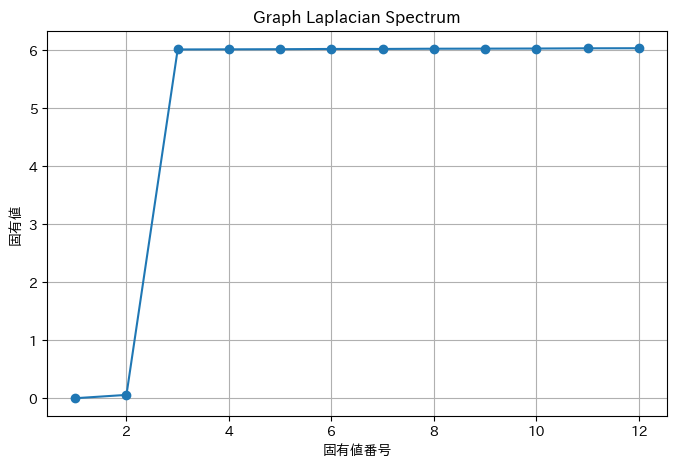

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(eigvals)+1),
    eigvals,
    marker='o'
)

plt.xlabel("固有値番号")
plt.ylabel("固有値")
plt.title("Graph Laplacian Spectrum")
plt.grid(True)

plt.show()

### 課題２

In [ ]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=0)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()